<a href="https://colab.research.google.com/github/mikhail-mat/mit-ocw_hands-on-deep-learning/blob/main/Standalone_Embeddings_GloVe_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Intro

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from scipy.sparse import lil_matrix

In [ ]:
keras.utils.set_random_seed(42)

In [ ]:
train_url = "https://www.dropbox.com/scl/fi/ito6bnl2yaf1uw0uqibzf/lyric_genre_train.csv?rlkey=04dkn5un2djza8x0bdmfnlw3u&st=y47qh8i4&dl=1"
val_url = "https://www.dropbox.com/scl/fi/xmywjzqsaa8n5sn1bs0t9/lyric_genre_val.csv?rlkey=hggbeo0s1iaxjpa6z80429xl9&st=6i7d8eau&dl=1"
test_url = "https://www.dropbox.com/scl/fi/fnocl69w9ojs9s5zb0xvf/lyric_genre_test.csv?rlkey=z4hjopw7vaihoh948cbb5mvdp&st=xwond7dp&dl=1"

train_df = pd.read_csv(train_url,index_col=0)
val_df = pd.read_csv(val_url,index_col=0)
test_df = pd.read_csv(test_url,index_col=0)

In [ ]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(48991, 2)
(16331, 2)
(21774, 2)


In [ ]:
train_df.head()

,Lyric,Genre
0,"Oh, girl. I can't get ready (Can't get ready f...",Pop
1,We met on a rainy evening in the summertime. D...,Pop
2,We carried you in our arms. On Independence Da...,Rock
3,I know he loved you. A long time ago. I ain't ...,Pop
4,Paralysis through analysis. Yellow moral uncle...,Rock


## Implementing GloVe from scratch

In [ ]:
text_vectorization = keras.layers.TextVectorization(
    max_tokens=3000,
    output_sequence_length=300,
    output_mode='int'
)

In [ ]:
# build the co-occurence matrix:
#   go through the corpus text using the predefined window size e.g. 2: how often
#   words appear together in the window 2 words before and after the current word

In [ ]:
text_vectorization.adapt(train_df['Lyric'])
vocab_size = text_vectorization.vocabulary_size()

In [ ]:
co_occurrence = lil_matrix((vocab_size, vocab_size))

vectorized_songs = text_vectorization(train_df['Lyric']).numpy()

for song in vectorized_songs:
    for i in range(len(song)):
        current = song[i]
        if current == 0:
          continue

        for j in range(i-3, i+4):
            if 0 <= j < len(song) and j != i:
                neighbor = song[j]
                if neighbor == 0:
                  continue
                co_occurrence[current, neighbor] += 1

co_occurrence = co_occurrence.tocoo()

from scipy.sparse import save_npz
save_npz("co_occurrence_matrix.npz", co_occurrence)

from google.colab import files
files.download("co_occurrence_matrix.npz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from scipy.sparse import load_npz
co_occurrence = load_npz("co_occurrence_matrix-3000-words.npz")

In [ ]:
words = co_occurrence.row
context = co_occurrence.col

counts = co_occurrence.data
log_counts = np.log(counts)

embedding_dim = 100 # embedding vectors will be 100 long

In [ ]:
# define a model by the formula: log(X(i,j)) = b(i) + b(j) + w(i)*w(j)

# the input are two integers representing the position in the co-occurence matrix
word_input = keras.layers.Input(shape=(1,))
context_input = keras.layers.Input(shape=(1,))

# create 100-long embedding vectors for the word and the context word
word_embedding = keras.layers.Embedding(
    input_dim=vocab_size, output_dim=embedding_dim
)(word_input)
context_embedding = keras.layers.Embedding(
    input_dim=vocab_size, output_dim=embedding_dim
)(context_input)

# add biases (natural occurence of both word and context word)
b_word = keras.layers.Embedding(input_dim=vocab_size, output_dim=1)(word_input)
b_context = keras.layers.Embedding(
    input_dim=vocab_size, output_dim=1
)(context_input)

# compute the dot product of the embedding vectors and add biases
dot = keras.layers.Dot(axes=-1)([word_embedding, context_embedding])
output = keras.layers.Add()([dot, b_word, b_context])
output = keras.layers.Flatten()(output)

model = keras.Model([word_input, context_input], output)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1, 100)    │    300,000 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 1, 100)    │    300,000 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, 1, 1)      │          0 │ embedding_8[0][0… │
│                     │                   │            │ embedding_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 1, 1)      │      3,000 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 1, 1)      │      3,000 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 1)      │          0 │ dot_1[0][0],      │
│                     │                   │            │ embedding_10[0][… │
│                     │                   │            │ embedding_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1)         │          0 │ add_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 606,000 (2.31 MB)

 Trainable params: 606,000 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [ ]:
model.fit(
    [words, context],
    log_counts,
    epochs=30,
    batch_size=512
)

Epoch 1/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 1.6258
Epoch 2/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.5595
Epoch 3/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.4952
Epoch 4/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.4442
Epoch 5/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.4076
Epoch 6/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3820
Epoch 7/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3658
Epoch 8/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3556
Epoch 9/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3488
Epoch 10/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.3440
Epoch 11/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3405
Epoch 12/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3377
Epoch 13/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3355
Epoch 14/30
4406/4406 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3337
Epoch 15/30
4406

In [ ]:
word_embeddings = model.layers[2].get_weights()[0]
context_embeddings = model.layers[3].get_weights()[0]

final_embeddings = word_embeddings + context_embeddings

In [ ]:
final_embeddings.shape

(3000, 100)

In [ ]:
final_embeddings[:3,:]

array([[ 1.89422853e-02, -6.85798749e-03,  2.58831680e-03,
        -7.96241388e-02,  1.91508420e-02,  6.47395626e-02,
        -1.72587857e-02, -1.21678039e-03, -6.53058290e-02,
        -2.85305530e-02,  5.73690310e-02, -1.19984373e-02,
         3.15420963e-02,  6.94471076e-02,  2.53806822e-02,
         8.16334784e-02, -7.42273331e-02,  6.08334914e-02,
         5.49202599e-02, -2.60064974e-02,  2.83116736e-02,
         3.06564569e-02, -7.15016276e-02, -3.34315822e-02,
        -2.33328938e-02,  1.75627246e-02,  2.63543017e-02,
         7.75009692e-02,  2.79489122e-02, -4.49321866e-02,
         4.62951586e-02, -4.90573421e-02,  4.87563983e-02,
        -5.03619686e-02, -2.24695075e-02,  5.55587187e-03,
         1.57356970e-02, -1.05649494e-02,  2.77890712e-02,
         4.04337421e-02, -1.60419792e-02,  2.44245771e-02,
         5.38196415e-03, -4.08107080e-02, -7.76226893e-02,
        -5.95689565e-02,  1.31601803e-02,  2.68193856e-02,
         7.50331283e-02, -4.55081947e-02,  5.31015359e-0

In [ ]:
final_embeddings[0] = 0
final_embeddings[1] = 0

## Create the classifier model for predicting genre using the standalone embeddings

In [ ]:
y_train = pd.get_dummies(train_df['Genre']).to_numpy(dtype='float32')
y_val = pd.get_dummies(val_df['Genre']).to_numpy(dtype='float32')
y_test = pd.get_dummies(test_df['Genre']).to_numpy(dtype='float32')

In [ ]:
X_train = text_vectorization(train_df['Lyric'])
X_val = text_vectorization(val_df['Lyric'])
X_test = text_vectorization(test_df['Lyric'])

In [ ]:
X_train

<tf.Tensor: shape=(48991, 300), dtype=int64, numpy=
array([[  40,   83,    4, ...,   22,  729,    3],
       [  20,  649,   13, ...,    0,    0,    0],
       [  20, 2872,    3, ...,    0,    0,    0],
       ...,
       [ 153,   66,   62, ...,    0,    0,    0],
       [ 119,   51,   13, ...,    0,    0,    0],
       [ 358,    1,    1, ...,    0,    0,    0]])>

In [ ]:
# classifier

input = keras.layers.Input(shape=(300,))

embedding = keras.layers.Embedding(
    input_dim=final_embeddings.shape[0],
    output_dim=embedding_dim,
    embeddings_initializer=keras.initializers.Constant(final_embeddings),
    trainable=False
)(input)

# embedding = keras.layers.GlobalAveragePooling1D()(embedding)

x = keras.layers.Dense(64, activation='relu')(embedding)

output = keras.layers.Dense(3, activation='softmax')(x)

classifier = keras.Model(input, output)
classifier.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_14 (Embedding)        │ (None, 300, 100)       │       300,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 300, 64)        │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 300, 3)         │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,659 (1.17 MB)

 Trainable params: 6,659 (26.01 KB)

 Non-trainable params: 300,000 (1.14 MB)

In [ ]:
classifier.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = classifier.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=10
)

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6330 - loss: 0.8230 - val_accuracy: 0.6988 - val_loss: 0.6906
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6958 - loss: 0.6984 - val_accuracy: 0.7049 - val_loss: 0.6757
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6997 - loss: 0.6852 - val_accuracy: 0.7099 - val_loss: 0.6663
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7025 - loss: 0.6773 - val_accuracy: 0.7121 - val_loss: 0.6619
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7053 - loss: 0.6713 - val_accuracy: 0.7146 - val_loss: 0.6576
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7075 - loss: 0.6669 - val_accuracy: 0.7142 - val_loss: 0.6549
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7080 - loss: 0.6639 - val_accuracy: 0.7154 - val_loss: 0.6524
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7091 - loss: 0.6612 - 

In [ ]:
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(loss_values) + 1)
  plt.plot(epochs, loss_values, "bo", label="Training loss")
  plt.plot(epochs, val_loss_values, "b", label="Validation loss")
  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

def plot_acc_curves(history):
  plt.clf()
  history_dict = history.history
  acc = history_dict["accuracy"]
  val_acc = history_dict["val_accuracy"]
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, "bo", label="Training acc")
  plt.plot(epochs, val_acc, "b", label="Validation acc")
  plt.title("Training and validation accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

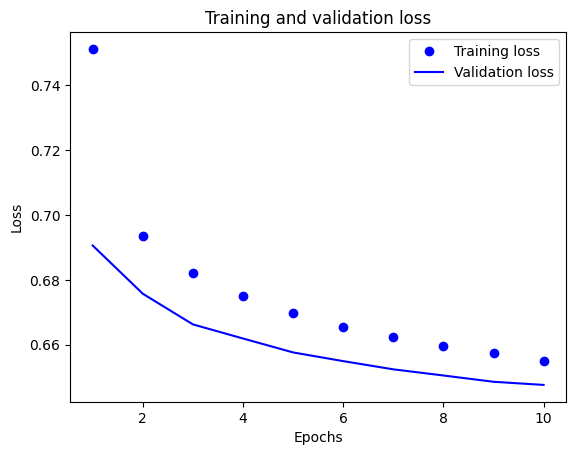

In [ ]:
plot_loss_curves(history)

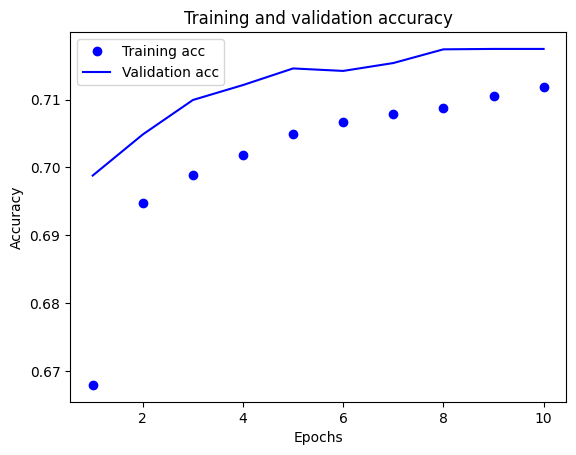

In [ ]:
plot_acc_curves(history)

In [ ]:
classifier.evaluate(X_test, y_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7139 - loss: 0.6551


[0.6634552478790283, 0.7094700336456299]